<hr>

**<h1><b> CS437/CS5317/EE414/EE513 Deep Learning | <span style="color: #9370DB;"> PA2 - Part 2</span></b></h1>**

<hr>

## <span style="color: #9370DB;">**Submission Guidelines**</span>

- <span style="color: #9370DB;">Please rename the file to `<RollNumber>_PA2_2`.</span>
- <span style="color: #9370DB;">Please also submit a **.py** file of every Notebook. You can do this by exporting your **ipynb** to a Python script.</span>
- <span style="color: #9370DB;">Please submit a zipped folder of both your Jupyter Notebooks and Python script files.</span>

<hr>

# **Autoencoders to U-Net: A Step-by-Step Approach to Medical Image Segmentation**

**Introduction**

Medical image segmentation is a fundamental problem in computer vision and deep learning, particularly in clinical applications where precise localization of anatomical structures and pathological regions is required. In this assignment, we study **liver and tumor segmentation from CT scans** using the **LiTS17 (Liver Tumor Segmentation)** dataset and progressively build deep learning models that evolve from simple reconstruction-based architectures to fully supervised segmentation networks.

The primary goal of this assignment is to understand **how architectural design choices influence performance** in dense prediction tasks. We begin with **autoencoders**, which learn compact latent representations by reconstructing input images, and gradually transition toward **segmentation-specific architectures** that explicitly model pixel-wise class predictions. This progression highlights why reconstruction alone is insufficient for segmentation and motivates the introduction of **skip connections**, as implemented in the **U-Net architecture**.

---

## **Dataset Description (LiTS17)**

We use the **LiTS17 dataset**, a widely used benchmark for liver and liver tumor segmentation from abdominal CT scans. The dataset consists of contrast-enhanced CT volumes along with expert-annotated segmentation masks.

Download from this link:
[/kaggle/input/lits17-liver-tumor-segmentation](https://www.kaggle.com/datasets/javariatahir123/lits17-liver-tumor-segmentation)

### **Data Format**
- CT volumes are stored in **NIfTI (`.nii`) format**
- Each volume is a **3D array** representing axial CT slices
- Corresponding segmentation masks have the same spatial dimensions

### **Directory Structure (Kaggle Mirror)**


- ├── CT_Vol/
-  └── CT_Vol/
-  └── volume-XXX.nii
- └── CT_Mask/
-  └── CT_Mask/
-  └── segmentation-XXX.nii


    
### **Segmentation Labels**
Each voxel in the segmentation mask belongs to one of the following classes:
- **0** → Background
- **1** → Liver
- **2** → Tumor

---

## **Key Challenges**

Segmentation on the LiTS dataset is challenging due to:
- **Severe class imbalance** (tumor regions are very small compared to background)
- **Low contrast boundaries** between liver and surrounding tissues
- **High inter-patient variability** in liver shape and tumor appearance
- The need to preserve **fine spatial details**, which are often lost in deep encoder–decoder models

These challenges make LiTS an ideal dataset for studying architectural improvements such as **skip connections** and **multi-scale feature fusion**.

---

## **Assignment Overview**

In this notebook, we follow a structured learning path:

1. **Data Exploration**
   - Load and visualize 3D CT volumes and segmentation masks
   - Inspect label distributions and slice-level variability

2. **Autoencoder-Based Models**
   - Train a **Convolutional Autoencoder** for image reconstruction
   - Extend it to a **Denoising Autoencoder** to improve robustness

3. **Segmentation as Dense Prediction**
   - Reformulate the task as **CT slice → segmentation mask**
   - Train a **Segmentation Autoencoder**
   - Analyze its limitations in capturing spatial detail

4. **U-Net Architecture**
   - Introduce skip connections between encoder and decoder
   - Train a **U-Net** for liver and tumor segmentation
   - Compare results with the segmentation autoencoder

5. **Evaluation & Visualization**
   - Report **Cross-Entropy loss** and **Dice score**
   - Visualize predictions using overlays
   - Export predicted volumes as **NIfTI files** for inspection in **MITK**

---

## **Outcome**

By the end of this assignment, students should have a clear understanding of:
- Why **autoencoders alone are insufficient** for segmentation
- How **skip connections improve spatial accuracy**
- The practical challenges of medical image segmentation
- How architectural choices directly impact quantitative and qualitative performance

<hr>

In [7]:
import os
os.listdir("/kaggle/input/datasets/javariatahir123/lits17-liver-tumor-segmentation")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/javariatahir123/lits17-liver-tumor-segmentation'

In [ ]:
# =========================
# Imports + Environment
# =========================
import os, re, random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# Mac/Jupyter safe
NUM_WORKERS = 0
PIN_MEMORY = False


Using device: cuda


## **Dataset Paths and Case Pairing**

This section defines dataset paths and pairs each CT volume with its corresponding segmentation mask using case IDs.  
Only cases with both a volume and a mask are retained for training and evaluation.

In [ ]:
# =========================
# Paths + Pair Cases
# =========================
DATASET_DIR = "/kaggle/input/datasets/javariatahir123/lits17-liver-tumor-segmentation"
VOL_DIR = os.path.join(DATASET_DIR, "CT_Vol", "CT_Vol")
MSK_DIR = os.path.join(DATASET_DIR, "CT_Mask", "CT_Mask")

def get_id(path):
    m = re.search(r"(\d+)", os.path.basename(path))
    return int(m.group(1)) if m else None

vols = [os.path.join(VOL_DIR, f) for f in os.listdir(VOL_DIR) if f.endswith(".nii")]
msks = [os.path.join(MSK_DIR, f) for f in os.listdir(MSK_DIR) if f.endswith(".nii")]

vol_map = {get_id(p): p for p in vols}
msk_map = {get_id(p): p for p in msks}

case_ids = sorted(set(vol_map) & set(msk_map))
print("Total paired cases:", len(case_ids))

Total paired cases: 131


## **CT Windowing and Overlay Visualization**

CT images are windowed using a fixed Hounsfield Unit (HU) range to enhance soft-tissue contrast.  
This section visualizes CT slices, segmentation masks, and their overlays to verify alignment and label quality.

In [ ]:
# =================================
# Windowing + Overlay Vizualization
# =================================
def window_hu(x, lo=-100, hi=400):
    x = np.clip(x, lo, hi)
    return (x - lo) / (hi - lo + 1e-8)

def show_overlay(ct2d, mask2d, title="", alpha=0.35):
    ct = window_hu(ct2d)
    plt.figure(figsize=(14,4))
    plt.subplot(1,3,1); plt.imshow(ct, cmap="gray"); plt.title(title+" CT"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask2d, cmap="gray"); plt.title(title+" Mask"); plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(ct, cmap="gray")
    plt.imshow(mask2d, alpha=alpha)
    plt.title(title+" Overlay")
    plt.axis("off")
    plt.show()

## **Tumor Case Selection and Slice Visualization**

A case containing tumor regions is selected to ensure meaningful visualization.  
Middle and tumor-containing slices are displayed with CT–mask overlays to inspect anatomy, tumor presence, and label correctness.

Using case: 0 | tumor exists: True
CT shape: (512, 512, 75) CT range: (np.float32(-3024.0), np.float32(1410.0))
Mask labels: [0 1 2]
mid_z: 37 | tumor_z: 65


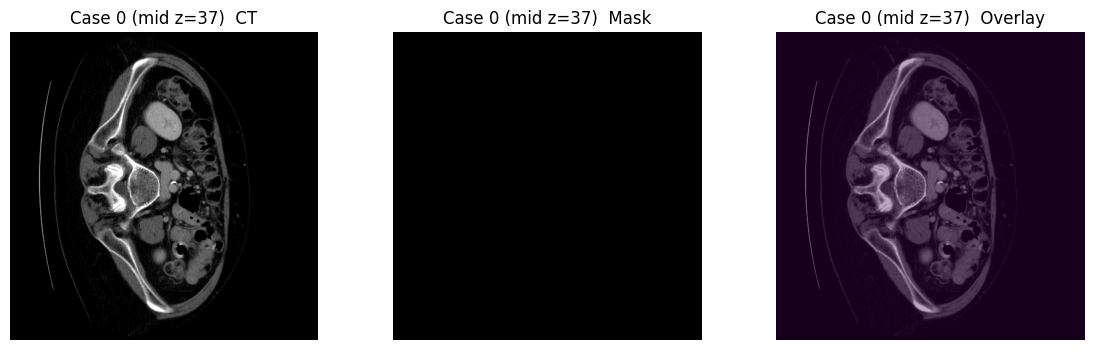

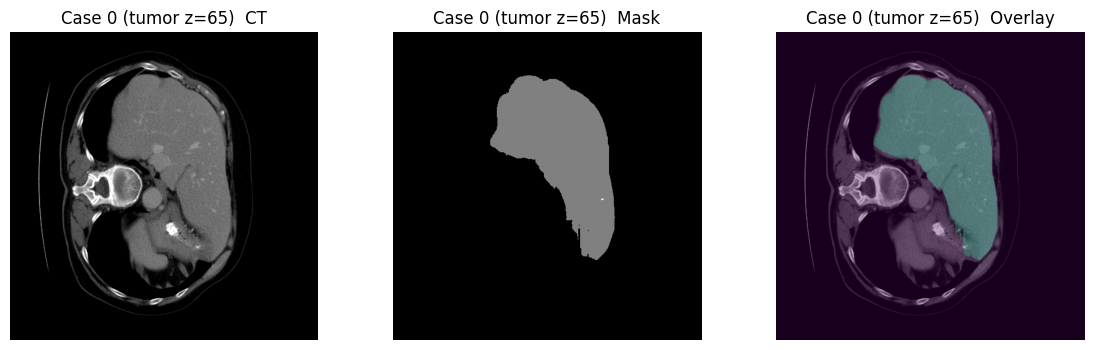

In [ ]:
# =========================
# Pick Tumor Case + Show Slices
# =========================
tumor_case = None
for cid in case_ids:
    S = nib.load(msk_map[cid]).get_fdata().astype(np.int16)
    if (S == 2).any():
        tumor_case = cid
        break

cid = tumor_case if tumor_case is not None else case_ids[0]
print("Using case:", cid, "| tumor exists:", tumor_case is not None)

V = nib.load(vol_map[cid]).get_fdata().astype(np.float32)
S = nib.load(msk_map[cid]).get_fdata().astype(np.int16)

Z = V.shape[-1]
mid_z = Z // 2

if (S == 2).any():
    tumor_slices = np.where((S == 2).reshape(-1, Z).any(axis=0))[0]
    tumor_z = int(tumor_slices[len(tumor_slices)//2])
else:
    tumor_z = mid_z

print("CT shape:", V.shape, "CT range:", (V.min(), V.max()))
print("Mask labels:", np.unique(S))
print("mid_z:", mid_z, "| tumor_z:", tumor_z)

show_overlay(V[..., mid_z], S[..., mid_z], title=f"Case {cid} (mid z={mid_z}) ")
show_overlay(V[..., tumor_z], S[..., tumor_z], title=f"Case {cid} (tumor z={tumor_z}) ")


## **Training and Validation Split Configuration**

The dataset is split into training and validation sets at the case level to prevent slice-level leakage.  
Model-specific epoch counts are defined, and output directories are initialized for saving results.


In [ ]:
# =========================
# Train/Val Split Config
# =========================
MAX_CASES = 25
TRAIN_FRAC = 0.8

EPOCHS_AE   = 6
EPOCHS_DAE  = 6
EPOCHS_SEG  = 10
EPOCHS_UNET = 15

RUN_DIR = "./Outputs_PA2_2"
os.makedirs(RUN_DIR, exist_ok=True)

all_cases = case_ids[:MAX_CASES]
random.shuffle(all_cases)

split = int(len(all_cases) * TRAIN_FRAC)
train_cases = sorted(all_cases[:split])
val_cases   = sorted(all_cases[split:])

print("Total cases used:", len(all_cases))
print("Train cases:", len(train_cases), "Val cases:", len(val_cases))

Total cases used: 25
Train cases: 20 Val cases: 5


## **Slice Dataset Construction**

CT volumes are converted into 2D slice-level samples for training.  
Only slices containing liver or tumor regions are retained, and volumes are optionally cached in memory to speed up data loading.


In [ ]:
# =========================
# Slice Dataset
# =========================
class LiTSSliceDataset(Dataset):
    """
    - list of (cid, z)
    - optional liver/tumor filtering
    - caches per-case volumes in RAM for speed
    """
    def __init__(self, case_ids, only_liver_slices=True, cache_in_ram=True):
        self.case_ids = list(case_ids)
        self.only_liver_slices = only_liver_slices
        self.cache_in_ram = cache_in_ram

        self.index = []
        self.cache = {}  # cid -> (V, S, affine, header)

        for cid in self.case_ids:
            V_img = nib.load(vol_map[cid])
            S_img = nib.load(msk_map[cid])

            V = V_img.get_fdata().astype(np.float32)
            S = S_img.get_fdata().astype(np.int16)

            if self.cache_in_ram:
                self.cache[cid] = (V, S, V_img.affine, V_img.header)

            Z = S.shape[-1]
            for z in range(Z):
                if (not self.only_liver_slices) or (S[..., z] > 0).any():
                    self.index.append((cid, z))

        random.shuffle(self.index)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        cid, z = self.index[i]

        if self.cache_in_ram:
            V, S, _, _ = self.cache[cid]
        else:
            V = nib.load(vol_map[cid]).get_fdata().astype(np.float32)
            S = nib.load(msk_map[cid]).get_fdata().astype(np.int16)

        x = window_hu(V[..., z])  # (H,W) in [0,1]
        y = S[..., z]             # (H,W) in {0,1,2}

        x = torch.tensor(x[None, ...], dtype=torch.float32)  # (1,H,W)
        y = torch.tensor(y, dtype=torch.long)                # (H,W)
        return x, y, cid, z

train_ds = LiTSSliceDataset(train_cases, only_liver_slices=True, cache_in_ram=True)
val_ds   = LiTSSliceDataset(val_cases,   only_liver_slices=True, cache_in_ram=True)

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train slices:", len(train_ds))
print("Val slices:", len(val_ds))

Train slices: 2949
Val slices: 920


## **Convolutional Autoencoder (Reconstruction Baseline)**

In this step, we train a **convolutional autoencoder** to reconstruct CT slices using an **encoder–decoder** architecture.  
The encoder compresses the input image into a lower-dimensional feature representation using convolution + pooling, and the decoder upsamples it back using transposed convolutions.

This model is trained with **Mean Squared Error (MSE)** between the input and reconstructed image.  
Although reconstruction is not segmentation, it builds intuition for encoder–decoder pipelines and shows how much spatial detail is lost when features are heavily compressed.

**Outputs in this section:**
- Training reconstruction loss curve (MSE)
- Side-by-side visualization of **input vs reconstructed CT slices**


In [ ]:
# =========================
# Conv Autoencoder 
# =========================
# TODOs marked clearly. Students must fill them.

class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()

        # TODO 1: Define encoder
        # Hint:
        # Conv2d(1→16) → ReLU → MaxPool
        # Conv2d(16→32) → ReLU → MaxPool
        self.enc = nn.Sequential(
            # TODO
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # (B, 16, H, W)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 16, H/2, W/2)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (B, 32, H/2, W/2)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 32, H/4, W/4)
        )

        # TODO 2: Define decoder
        # Hint:
        # ConvTranspose2d(32→16) → ReLU
        # ConvTranspose2d(16→1) → Sigmoid
        self.dec = nn.Sequential(
            # TODO
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # (B, 16, H/2, W/2)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),   # (B, 1, H, W)
            nn.Sigmoid()
        )

    def forward(self, x):
        # TODO 3: Encode then decode
        z = self.enc(x)
        return self.dec(z)


# Reconstruction DataLoader 
recon_dl = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

[AE] ep 1 iter 0/369
[AE] ep 1 iter 50/369
[AE] ep 1 iter 100/369
[AE] ep 1 iter 150/369
[AE] ep 1 iter 200/369
[AE] ep 1 iter 250/369
[AE] ep 1 iter 300/369
[AE] ep 1 iter 350/369
[AE] Epoch 1/6 | recon MSE=0.0257
[AE] ep 2 iter 0/369
[AE] ep 2 iter 50/369
[AE] ep 2 iter 100/369
[AE] ep 2 iter 150/369
[AE] ep 2 iter 200/369
[AE] ep 2 iter 250/369
[AE] ep 2 iter 300/369
[AE] ep 2 iter 350/369
[AE] Epoch 2/6 | recon MSE=0.0017
[AE] ep 3 iter 0/369
[AE] ep 3 iter 50/369
[AE] ep 3 iter 100/369
[AE] ep 3 iter 150/369
[AE] ep 3 iter 200/369
[AE] ep 3 iter 250/369
[AE] ep 3 iter 300/369
[AE] ep 3 iter 350/369
[AE] Epoch 3/6 | recon MSE=0.0015
[AE] ep 4 iter 0/369
[AE] ep 4 iter 50/369
[AE] ep 4 iter 100/369
[AE] ep 4 iter 150/369
[AE] ep 4 iter 200/369
[AE] ep 4 iter 250/369
[AE] ep 4 iter 300/369
[AE] ep 4 iter 350/369
[AE] Epoch 4/6 | recon MSE=0.0013
[AE] ep 5 iter 0/369
[AE] ep 5 iter 50/369
[AE] ep 5 iter 100/369
[AE] ep 5 iter 150/369
[AE] ep 5 iter 200/369
[AE] ep 5 iter 250/369
[AE] 

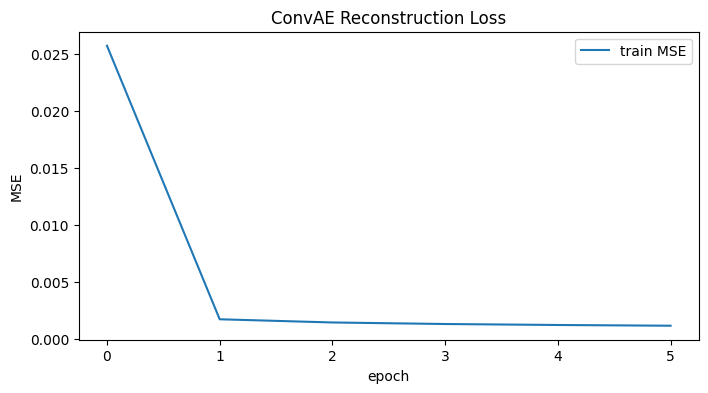

In [ ]:
# =========================
# Train ConvAE 
# =========================

# Initialize model
ae = ConvAE().to(device)

# Optimizer
opt = optim.Adam(ae.parameters(), lr=1e-3)

# Loss function
mse = nn.MSELoss()

ae_losses = []
import time
for ep in range(1, EPOCHS_AE + 1):
    ae.train()
    t0 = time.time()
    run = 0.0

    for it, (x, _, _, _) in enumerate(recon_dl):
        if it % 50 == 0:
            print(f"[AE] ep {ep} iter {it}/{len(recon_dl)}")

        x = x.to(device)

        out = ae(x)
        loss = mse(out, x)

        opt.zero_grad()
        loss.backward()
        opt.step()

        run += loss.item()

    avg = run / len(recon_dl)
    ae_losses.append(avg)

    print(f"[AE] Epoch {ep}/{EPOCHS_AE} | recon MSE={avg:.4f}")


# -------- DO NOT MODIFY BELOW --------
plt.figure(figsize=(8,4))
plt.plot(ae_losses, label="train MSE")
plt.title("ConvAE Reconstruction Loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

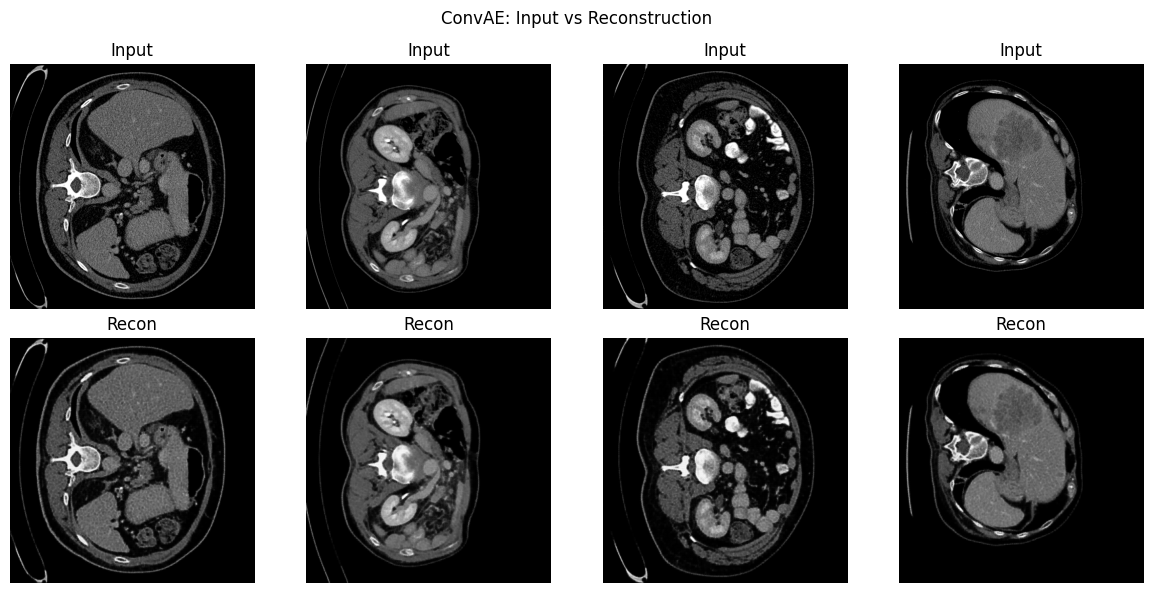

In [ ]:
# =========================
# Visualize Reconstructions
# =========================
ae.eval()
x, _, _, _ = next(iter(recon_dl))
x = x.to(device)

with torch.no_grad():
    recon = ae(x)

plt.figure(figsize=(12,6))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(x[i,0].detach().cpu().numpy(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(recon[i,0].detach().cpu().numpy(), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.suptitle("ConvAE: Input vs Reconstruction")
plt.tight_layout()
plt.show()


## **Denoising Autoencoder (Robust Reconstruction)**

A denoising autoencoder is trained to reconstruct the **clean CT slice** from a **noisy input**.  
During training, Gaussian noise is added to each input image, forcing the model to learn more stable and meaningful features instead of simply copying pixel values.

The model is still optimized using **MSE reconstruction loss**, but the learning objective is harder:  
**noisy CT → clean CT**.

After training, we visualize the denoising effect by adding a stronger amount of noise at inference time and comparing:
- the original clean image
- the heavily corrupted noisy image
- the denoised reconstruction produced by the model

This helps build intuition for why feature learning and robustness matter before moving to segmentation.


In [ ]:
# =========================
# Denoising Autoencoder 
# =========================
# Students implement the noise injection logic.

class DenoisingWrapper(nn.Module):
    def __init__(self, ae, noise_std=0.1):
        super().__init__()
        self.ae = ae
        self.noise_std = noise_std

    def forward(self, x):
        # TODO 1: During training, add Gaussian noise:
        #   noise = torch.randn_like(x) * self.noise_std
        #   x_noisy = clamp(x + noise, 0, 1)
        # Then pass through self.ae(...)
        #
        # Hint: use `self.training` to check training mode
       if self.training:
            noise = torch.randn_like(x) * self.noise_std
            x = torch.clamp(x + noise, 0, 1)
       return self.ae(x)

[DAE] Epoch 1/6 | MSE=0.0017
[DAE] Epoch 2/6 | MSE=0.0016
[DAE] Epoch 3/6 | MSE=0.0015
[DAE] Epoch 4/6 | MSE=0.0015
[DAE] Epoch 5/6 | MSE=0.0015
[DAE] Epoch 6/6 | MSE=0.0014


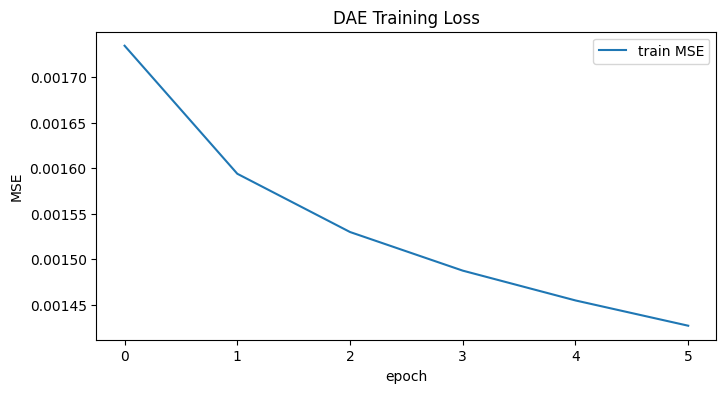

In [ ]:
# =========================
# Train DAE
# ========================
# Goal: learn to reconstruct clean CT slices from noisy inputs

# Model (wrap ConvAE inside denoising wrapper)
dae = DenoisingWrapper(ae, noise_std=0.1).to(device)

# Optimizer for model parameters
opt = optim.Adam(dae.parameters(), lr=1e-3)

# Reconstruction loss
mse = nn.MSELoss()

dae_losses = []

for ep in range(1, EPOCHS_DAE + 1):
    # Enable training behavior (noise should be injected)
    dae.train()
    run = 0.0

    for x, _, _, _ in recon_dl:
        # Move batch to correct device
        x = x.to(device)

        # Forward pass through denoising model
        out = dae(x)        # noisy input → clean reconstruction

        # Compare reconstruction against clean input
        loss = loss = mse(out, x)  # compare against clean original

        # Standard optimization step
        opt.zero_grad()
        loss.backward()
        opt.step()

        run += loss.item()

    # Track average epoch loss
    avg = run / len(recon_dl)
    dae_losses.append(avg)

    print(f"[DAE] Epoch {ep}/{EPOCHS_DAE} | MSE={avg:.4f}")


# -------- DO NOT MODIFY BELOW --------
plt.figure(figsize=(8,4))
plt.plot(dae_losses, label="train MSE")
plt.title("DAE Training Loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

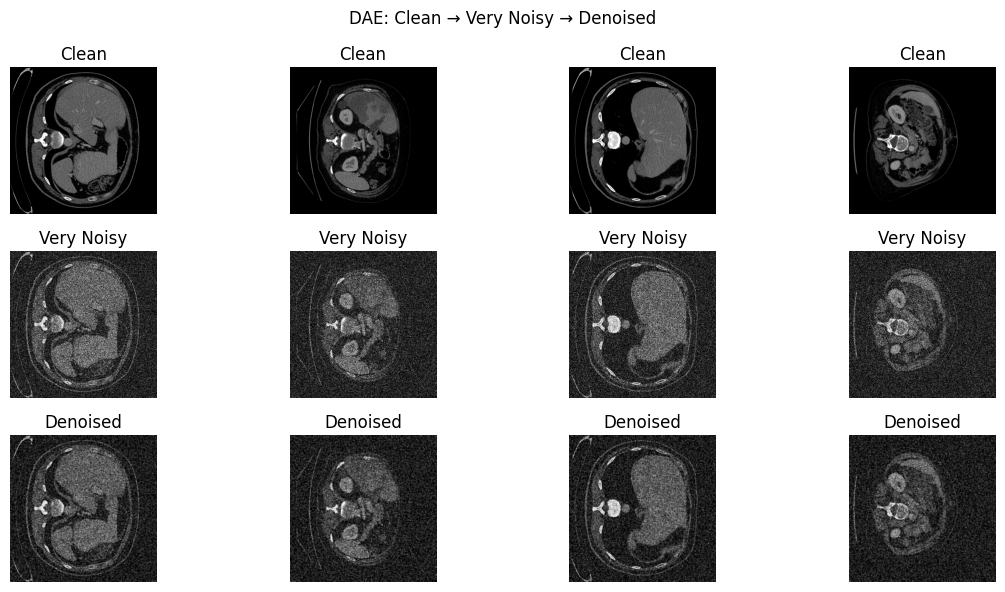

In [ ]:
# =========================
# Visualize Denoising Effect
# =========================
dae.eval()
x, _, _, _ = next(iter(recon_dl))
x = x.to(device)

STRONG_NOISE_STD = 0.35
with torch.no_grad():
    noisy = torch.clamp(x + torch.randn_like(x) * STRONG_NOISE_STD, 0, 1)
    recon = dae(noisy)

plt.figure(figsize=(12,6))
for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(x[i,0].detach().cpu().numpy(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(3,4,i+5)
    plt.imshow(noisy[i,0].detach().cpu().numpy(), cmap="gray")
    plt.title("Very Noisy")
    plt.axis("off")

    plt.subplot(3,4,i+9)
    plt.imshow(recon[i,0].detach().cpu().numpy(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("DAE: Clean → Very Noisy → Denoised")
plt.tight_layout()
plt.show()


## **Evaluation Metrics and Training Utilities (CE + Dice)**

To evaluate segmentation performance, we use two key metrics:

- **Cross-Entropy Loss (CE):** measures how well the predicted class probabilities match the ground-truth labels during training.
- **Dice Score:** measures overlap between predicted and ground-truth masks. Since background dominates CT images, we report a **single Dice score averaged over liver (class 1) and tumor (class 2)**.

This section also includes helper functions to:
- compute mean Dice (liver + tumor)
- evaluate a model on the validation set (Val CE + Val Dice)
- visualize predictions as CT overlays
- train any segmentation model with clean epoch-wise logging and simple curves


In [ ]:
# =========================
# Dice + Evaluation Helpers
# =========================

@torch.no_grad()
def mean_dice_liver_tumor(pred, target, eps=1e-6):
    """
    pred:   (B,H,W) predicted class labels
    target: (B,H,W) ground truth class labels
    returns: scalar mean Dice over classes 1 and 2
    """
    dices = []
    for c in [1, 2]:
        pred_c = (pred == c).float()
        targ_c = (target == c).float()

        inter = (pred_c * targ_c).sum(dim=(1, 2))
        union = pred_c.sum(dim=(1, 2)) + targ_c.sum(dim=(1, 2))

        dice = (2 * inter + eps) / (union + eps)   # (B,)
        dices.append(dice.mean().item())

    return float(sum(dices) / len(dices))

@torch.no_grad()
def evaluate_segmentation(model, loader):
    """
    Returns:
      avg_val_ce, avg_val_dice
    """
    model.eval()
    ce = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_dice = 0.0
    batches = 0

    for x, y, _, _ in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = ce(logits, y)
        total_loss += loss.item()

        pred = torch.argmax(logits, dim=1)
        total_dice += mean_dice_liver_tumor(pred, y)

        batches += 1

    return total_loss / batches, total_dice / batches

@torch.no_grad()
def visualize_batch_predictions(model, loader, n=4, title=""):
    model.eval()
    x, y, _, _ = next(iter(loader))
    x, y = x.to(device), y.to(device)
    pred = torch.argmax(model(x), dim=1)

    plt.figure(figsize=(14, 6))
    for i in range(min(n, x.size(0))):
        ct = x[i, 0].detach().cpu().numpy()
        gt = y[i].detach().cpu().numpy()
        pr = pred[i].detach().cpu().numpy()

        plt.subplot(3, n, i+1)
        plt.imshow(ct, cmap="gray"); plt.title("CT"); plt.axis("off")

        plt.subplot(3, n, i+1+n)
        plt.imshow(ct, cmap="gray"); plt.imshow(gt, alpha=0.35)
        plt.title("GT overlay"); plt.axis("off")

        plt.subplot(3, n, i+1+2*n)
        plt.imshow(ct, cmap="gray"); plt.imshow(pr, alpha=0.35)
        plt.title("Pred overlay"); plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def train_seg_model(model, train_dl, val_dl, epochs, lr=1e-3, title="model"):
    """
    Prints:
      [title] Epoch xx/yy | Train CE=... | Val CE=... | Val Dice=...
    Returns model and history arrays.
    """
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()

    train_ce_hist = []
    val_ce_hist = []
    val_dice_hist = []

    for ep in range(1, epochs + 1):
        model.train()
        run = 0.0

        for x, y, _, _ in train_dl:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = ce(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            run += loss.item()

        train_ce = run / len(train_dl)
        val_ce, val_dice = evaluate_segmentation(model, val_dl)

        train_ce_hist.append(train_ce)
        val_ce_hist.append(val_ce)
        val_dice_hist.append(val_dice)

        print(f"[{title}] Epoch {ep:02d}/{epochs} | Train CE={train_ce:.4f} | Val CE={val_ce:.4f} | Val Dice={val_dice:.4f}")

    # Curves (simple)
    plt.figure(figsize=(10,4))
    plt.plot(train_ce_hist, label="Train CE")
    plt.plot(val_ce_hist, label="Val CE")
    plt.title(f"{title}: Cross-Entropy Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(val_dice_hist, label="Val Dice (mean liver+tumor)")
    plt.title(f"{title}: Validation Dice")
    plt.xlabel("epoch"); plt.ylabel("dice"); plt.legend(); plt.show()

    return model, (train_ce_hist, val_ce_hist, val_dice_hist)


## **Segmentation Autoencoder (CT Slice → Mask Prediction)**

Here we shift from reconstruction to **supervised segmentation**.  
Instead of predicting the input image, the model learns a direct mapping:

**CT slice → segmentation mask (background / liver / tumor)**

This architecture is similar to an autoencoder (encoder–decoder), but the decoder outputs **3-channel logits** corresponding to the three segmentation classes. The model is trained using **Cross-Entropy loss**, and performance is reported using a single **mean Dice score over liver and tumor**.

This model acts as a baseline segmentation network, but it often struggles with fine boundaries because spatial details can be lost after downsampling. This limitation motivates the next step: **U-Net skip connections**.

**Outputs in this section:**
- Training logs: **Train CE, Val CE, Val Dice**
- Overlay visualizations: **CT + GT mask** vs **CT + predicted mask**


[SegAE] Epoch 01/10 | Train CE=0.2589 | Val CE=0.1209 | Val Dice=0.5669
[SegAE] Epoch 02/10 | Train CE=0.1074 | Val CE=0.1134 | Val Dice=0.6201
[SegAE] Epoch 03/10 | Train CE=0.1006 | Val CE=0.1101 | Val Dice=0.6369
[SegAE] Epoch 04/10 | Train CE=0.0975 | Val CE=0.1100 | Val Dice=0.6277
[SegAE] Epoch 05/10 | Train CE=0.0956 | Val CE=0.1051 | Val Dice=0.6425
[SegAE] Epoch 06/10 | Train CE=0.0945 | Val CE=0.1041 | Val Dice=0.6602
[SegAE] Epoch 07/10 | Train CE=0.0936 | Val CE=0.1065 | Val Dice=0.6525
[SegAE] Epoch 08/10 | Train CE=0.0929 | Val CE=0.1046 | Val Dice=0.6596
[SegAE] Epoch 09/10 | Train CE=0.0921 | Val CE=0.1040 | Val Dice=0.6370
[SegAE] Epoch 10/10 | Train CE=0.0923 | Val CE=0.1126 | Val Dice=0.5992


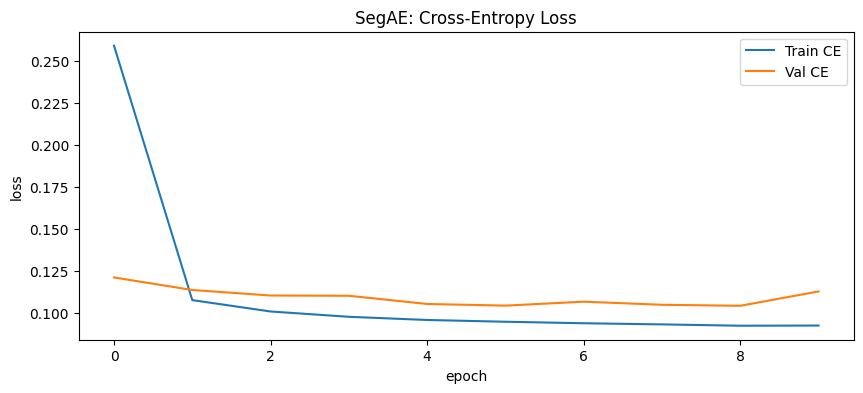

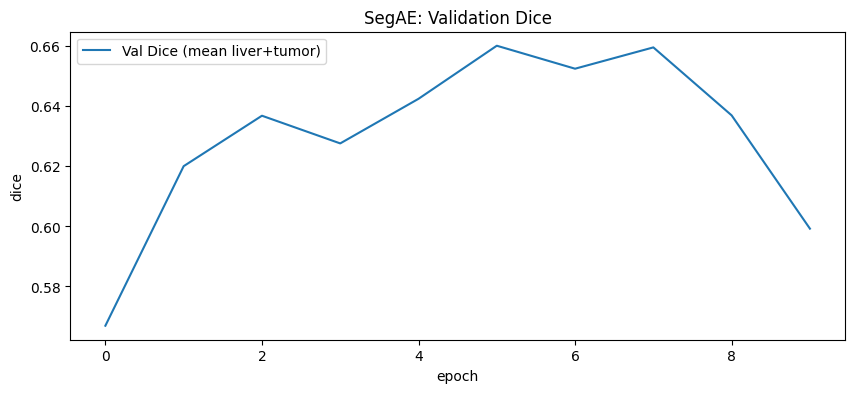

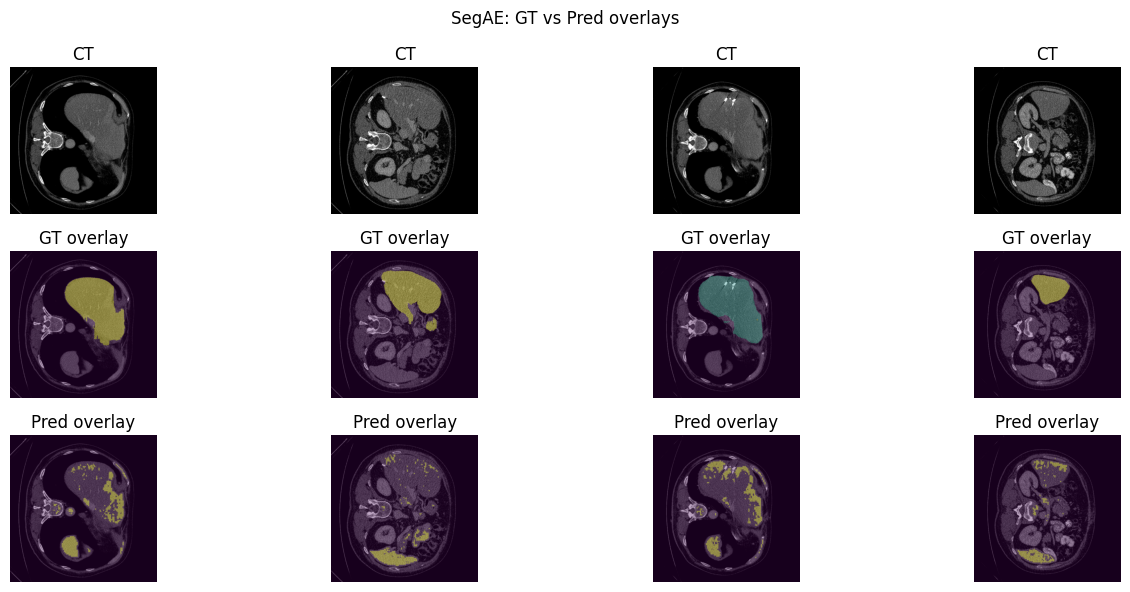

In [ ]:
# =========================
# Segmentation Autoencoder 
# =========================
# Goal: CT slice (1 channel) → segmentation logits (3 classes: 0/1/2)

class SegmentationAE(nn.Module):
    def __init__(self):
        super().__init__()

        # TODO 1: Define encoder (same idea as ConvAE encoder)
        # Hint:
        # Conv2d(1→16) → ReLU → MaxPool
        # Conv2d(16→32) → ReLU → MaxPool
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # (B, 16, H, W)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 16, H/2, W/2)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (B, 32, H/2, W/2)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 32, H/4, W/4)
        )

        # TODO 2: Define decoder that outputs 3 channels (logits)
        # Hint:
        # ConvTranspose2d(32→16) → ReLU
        # ConvTranspose2d(16→3)
        # (No sigmoid/softmax here because CrossEntropyLoss expects raw logits)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # (B, 16, H/2, W/2)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=2, stride=2)    # (B, 3, H, W)
        )

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)  # (B, 3, H, W) logits


# TODO 4: Initialize model
seg_model = SegmentationAE()  # SegmentationAE()

# TODO 5: Train using the helper (already defined earlier)
# This prints: Train CE, Val CE, Val Dice
seg_model, seg_hist = train_seg_model(
    seg_model,
    train_dl,
    val_dl,
    epochs=EPOCHS_SEG,
    title="SegAE" 
)

# -------- DO NOT MODIFY BELOW --------
visualize_batch_predictions(seg_model, val_dl, n=4, title="SegAE: GT vs Pred overlays")


## **U-Net Architecture (Skip Connections for Better Segmentation)**

U-Net is a specialized encoder–decoder network designed for **medical image segmentation**.  
Unlike a standard segmentation autoencoder, U-Net introduces **skip connections** that directly pass high-resolution feature maps from the encoder to the decoder. This helps the decoder recover **fine spatial details** (edges, boundaries, small tumor regions) that are often lost during downsampling.

### **Why Skip Connections Matter**
In segmentation, we need both:
- **Global context** (where the liver is overall) → learned in deeper layers  
- **Local detail** (exact boundaries, small tumors) → preserved in early layers  

Skip connections combine these by concatenating encoder features with decoder features at matching resolutions, improving localization.

### **What This Section Does**
- Defines a small U-Net with:
  - two encoder blocks + bottleneck
  - two decoder blocks with skip connections
  - final 1×1 convolution producing logits for 3 classes (0/1/2)
- Trains the model using **Cross-Entropy loss**
- Evaluates using a single **mean Dice score over liver and tumor**
- Visualizes predictions with CT overlays for qualitative comparison

This is the final model in the notebook and represents the main architectural upgrade from autoencoders to a strong segmentation baseline.


[U-Net] Epoch 01/15 | Train CE=0.1558 | Val CE=0.0928 | Val Dice=0.7139
[U-Net] Epoch 02/15 | Train CE=0.0643 | Val CE=0.0590 | Val Dice=0.5186
[U-Net] Epoch 03/15 | Train CE=0.0520 | Val CE=0.0781 | Val Dice=0.4487
[U-Net] Epoch 04/15 | Train CE=0.0445 | Val CE=0.0815 | Val Dice=0.5789
[U-Net] Epoch 05/15 | Train CE=0.0391 | Val CE=0.0600 | Val Dice=0.5817
[U-Net] Epoch 06/15 | Train CE=0.0350 | Val CE=0.0543 | Val Dice=0.5832
[U-Net] Epoch 07/15 | Train CE=0.0321 | Val CE=0.0666 | Val Dice=0.5702
[U-Net] Epoch 08/15 | Train CE=0.0305 | Val CE=0.0594 | Val Dice=0.5724
[U-Net] Epoch 09/15 | Train CE=0.0280 | Val CE=0.0415 | Val Dice=0.6093
[U-Net] Epoch 10/15 | Train CE=0.0260 | Val CE=0.0356 | Val Dice=0.7078
[U-Net] Epoch 11/15 | Train CE=0.0257 | Val CE=0.0423 | Val Dice=0.6706
[U-Net] Epoch 12/15 | Train CE=0.0238 | Val CE=0.0339 | Val Dice=0.6833
[U-Net] Epoch 13/15 | Train CE=0.0227 | Val CE=0.0375 | Val Dice=0.7614
[U-Net] Epoch 14/15 | Train CE=0.0219 | Val CE=0.0385 | Val Dice

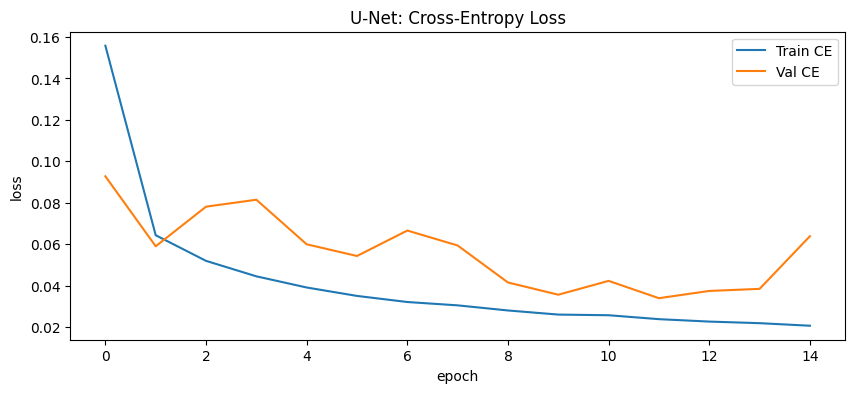

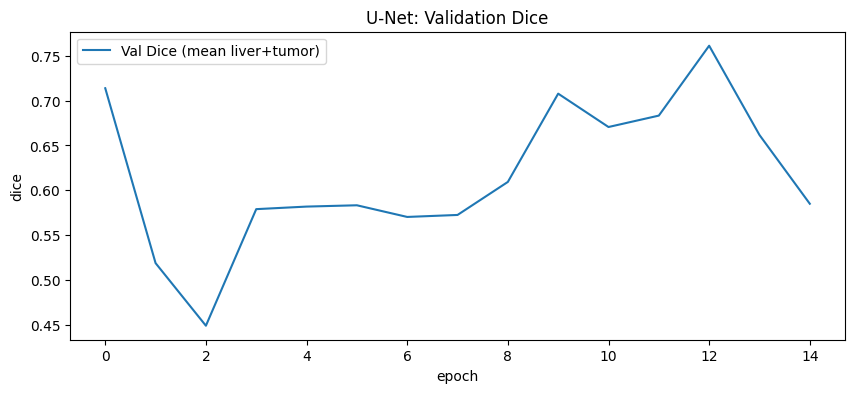

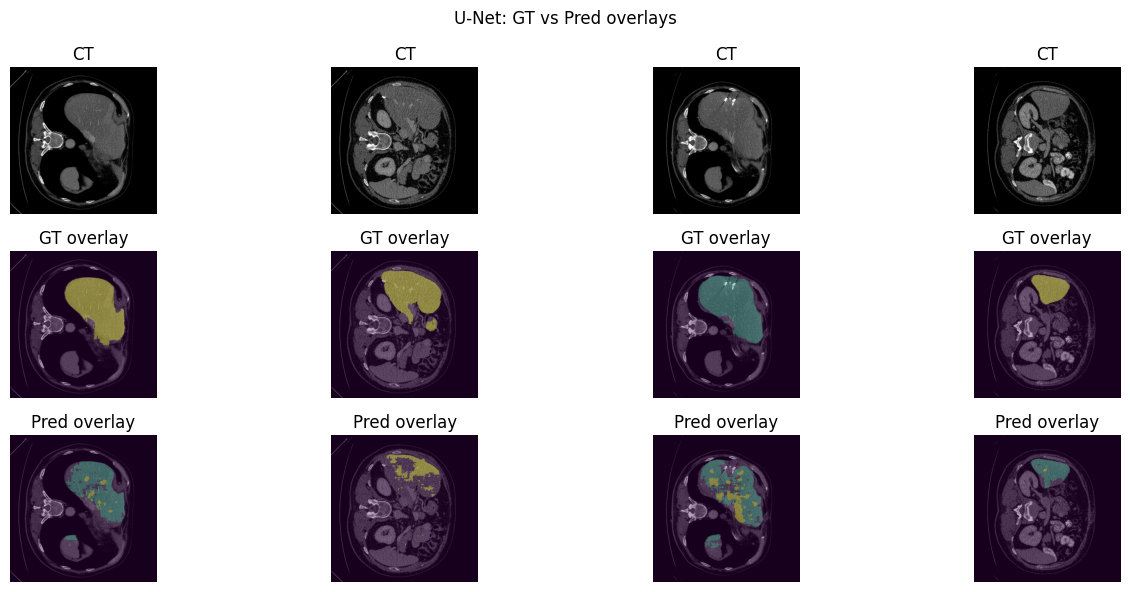

In [ ]:
# =========================
# U-Net
# =========================
# Goal: implement U-Net using ONLY the shape hints below.
# You must decide the layers yourself.

import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        base = 32  # you can change this (e.g., 16 for faster, 64 for stronger)

        # Encoder stage 1
        # Input:  (B, 1, H, W)
        # Output: (B, base, H, W)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)   # reduces spatial size by 2

        # Encoder stage 2
        # Input:  (B, base, H/2, W/2)
        # Output: (B, 2*base, H/2, W/2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(base, 2*base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(2*base),
            nn.ReLU(inplace=True),
            nn.Conv2d(2*base, 2*base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(2*base),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)   # reduces spatial size by 2

        # Bottleneck
        # Input:  (B, 2*base, H/4, W/4)
        # Output: (B, 4*base, H/4, W/4)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(2*base, 4*base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(4*base),
            nn.ReLU(inplace=True),
            nn.Conv2d(4*base, 4*base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(4*base),
            nn.ReLU(inplace=True),
        )

        # Decoder stage 2
        # Upsample to: (B, 2*base, H/2, W/2)
        # Skip connection from enc2
        self.up2 = nn.ConvTranspose2d(4*base, 2*base, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(4*base, 2*base, kernel_size=3, padding=1, bias=False),  # concat => 2*base + 2*base
            nn.BatchNorm2d(2*base),
            nn.ReLU(inplace=True),
            nn.Conv2d(2*base, 2*base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(2*base),
            nn.ReLU(inplace=True),
        )

        # Decoder stage 1
        # Upsample to: (B, base, H, W)
        # Skip connection from enc1
        self.up1 = nn.ConvTranspose2d(2*base, base, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(2*base, base, kernel_size=3, padding=1, bias=False),  # concat => base + base
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, base, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
        )

        # Output layer
        # Output: (B, 3, H, W)  ← 3 segmentation classes
        self.out = nn.Conv2d(base, 3, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)       # save for skip connection (H, W)
        p1 = self.pool1(x1)     # (H/2, W/2)

        x2 = self.enc2(p1)      # save for skip connection (H/2, W/2)
        p2 = self.pool2(x2)     # (H/4, W/4)

        # Bottleneck
        b = self.bottleneck(p2) # (H/4, W/4)

        # Decoder
        u2 = self.up2(b)        # upsampled to (H/2, W/2)
        # concatenate with x2 along channel dimension
        d2 = self.dec2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(d2)       # upsampled to (H, W)
        # concatenate with x1 along channel dimension
        d1 = self.dec1(torch.cat([u1, x1], dim=1))

        # Output logits
        out = self.out(d1)      # (B, 3, H, W)
        return out


# Train + visualize (helpers already implemented earlier)
unet = UNet()
unet, unet_hist = train_seg_model(
    unet,
    train_dl,
    val_dl,
    epochs=EPOCHS_UNET,
    title="U-Net"
)

# -------- DO NOT MODIFY BELOW --------
visualize_batch_predictions(unet, val_dl, n=4, title="U-Net: GT vs Pred overlays")

## **Exporting Predictions to NIfTI for MITK Visualization**

This section exports model predictions in **NIfTI (.nii.gz)** format so they can be inspected in **MITK** alongside the original CT scans.

For each selected case, we:
- run slice-wise inference to build a **3D prediction volume**
- save the **predicted segmentation mask** (labels 0/1/2)
- save the **ground-truth mask** for comparison
- save the original **CT volume** for overlay visualization

Predictions are converted to **integer label maps** using `argmax` and stored with the correct affine and header to ensure proper spatial alignment in MITK.

These exported files allow qualitative evaluation of:
- segmentation quality
- alignment between CT, ground truth, and predictions
- differences between Segmentation Autoencoder and U-Net outputs


In [ ]:
# =========================
# Export NIfTI for MITK
# =========================
@torch.no_grad()
def predict_case_volume(model, cid, use_window=True):
    model.eval()

    V_img = nib.load(vol_map[cid])
    V = V_img.get_fdata().astype(np.float32)
    H, W, Z = V.shape

    pred_vol = np.zeros((H, W, Z), dtype=np.uint8)

    for z in range(Z):
        ct = V[..., z]
        if use_window:
            ct = window_hu(ct)

        x = torch.tensor(ct[None, None, ...], dtype=torch.float32).to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy().astype(np.uint8)
        pred_vol[..., z] = pred

    return pred_vol, V_img.affine, V_img.header

def save_nifti(volume, affine, header, out_path):
    img = nib.Nifti1Image(volume, affine, header=header)
    nib.save(img, out_path)
    print("Saved:", out_path)

def export_predictions_for_mitk(model, cids, tag="unet"):
    out_dir = os.path.join(RUN_DIR, f"mitk_exports_{tag}")
    os.makedirs(out_dir, exist_ok=True)

    for cid in cids:
        pred_vol, aff, hdr = predict_case_volume(model, cid)
        save_nifti(pred_vol, aff, hdr, os.path.join(out_dir, f"pred_case_{cid:03d}.nii.gz"))

        gt_img = nib.load(msk_map[cid])
        gt_vol = gt_img.get_fdata().astype(np.uint8)
        save_nifti(gt_vol, gt_img.affine, gt_img.header, os.path.join(out_dir, f"gt_case_{cid:03d}.nii.gz"))

        ct_img = nib.load(vol_map[cid])
        ct_vol = ct_img.get_fdata().astype(np.float32)
        save_nifti(ct_vol, ct_img.affine, ct_img.header, os.path.join(out_dir, f"ct_case_{cid:03d}.nii.gz"))

    print("MITK export folder:", out_dir)

# Export a few validation cases
export_predictions_for_mitk(seg_model, val_cases[:3], tag="segae")
export_predictions_for_mitk(unet,     val_cases[:3], tag="unet")


Saved: ./Outputs_PA2_2/mitk_exports_segae/pred_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/gt_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/ct_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/pred_case_011.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/gt_case_011.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/ct_case_011.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/pred_case_017.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/gt_case_017.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_segae/ct_case_017.nii.gz
MITK export folder: ./Outputs_PA2_2/mitk_exports_segae
Saved: ./Outputs_PA2_2/mitk_exports_unet/pred_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_unet/gt_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_unet/ct_case_009.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_unet/pred_case_011.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_unet/gt_case_011.nii.gz
Saved: ./Outputs_PA2_2/mitk_exports_unet/ct_case_011.nii.gz
Saved: ./Outputs_PA2_2/mit

In [ ]:
!zip -r PA2_2_MITK_exports.zip /kaggle/working/Outputs_PA2_2/

  adding: kaggle/working/Outputs_PA2_2/ (stored 0%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/ (stored 0%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/pred_case_009.nii.gz (deflated 68%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/gt_case_009.nii.gz (deflated 70%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/gt_case_017.nii.gz (deflated 72%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/pred_case_011.nii.gz (deflated 57%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/ct_case_009.nii.gz (deflated 0%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/ct_case_011.nii.gz (deflated 0%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/pred_case_017.nii.gz (deflated 61%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/ct_case_017.nii.gz (deflated 0%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_unet/gt_case_011.nii.gz (deflated 60%)
  adding: kaggle/working/Outputs_PA2_2/mitk_exports_sega

In [ ]:
from IPython.display import FileLink
FileLink("PA2_2_MITK_exports.zip")

/kaggle/working/PA2_2_MITK_exports.zip

## **MITK Visualization and Model Comparison**

In this section, you will perform **qualitative evaluation** of your segmentation models using **MITK**.

### **Instructions**
1. Export the following NIfTI volumes for the **same case(s)**:
   - CT volume
   - Ground truth mask
   - Predicted mask from:
     - **Segmentation Autoencoder**
     - **U-Net**

2. Open the volumes in **MITK** and:
   - Overlay the **ground truth mask** on the CT scan
   - Overlay the **predicted mask** on the same CT scan
   - Use identical visualization settings (opacity, slice index, color maps)

3. Take clear **screenshots** in MITK showing:
   - CT + Ground Truth
   - CT + Segmentation Autoencoder prediction
   - CT + U-Net prediction

4. **Paste the screenshots directly in this notebook** below this cell.

---

### **Comparison and Analysis (Answer in Markdown)**
After inserting the screenshots, briefly discuss:

- How do the predictions of the **Segmentation Autoencoder** differ from the **U-Net**?
- Which model preserves liver boundaries better?
- Which model captures tumor regions more reliably?
- How do skip connections affect spatial detail and anatomical consistency?

Your discussion should clearly relate the visual differences to the **architectural differences** between the two models.

> **Note:** This qualitative comparison is mandatory and will be graded alongside quantitative metrics (Dice score).


## MITK Visualization Results

### Case 000

#### CT + Segmentation Autoencoder
![Case 000 SegAE](images/case_000_seg_ae.png)

#### CT + U-Net
![Case 000 UNet](images/unet_case_000.png)

---

### Case 003

#### CT + Segmentation Autoencoder
![Case 003 SegAE](images/case_003_seg_ae.png)

#### CT + U-Net
![Case 003 UNet](images/unet_case_003.png)

---

### Case 007

#### CT + Segmentation Autoencoder
![Case 007 SegAE](images/case_007_seg_ae.png)

#### CT + U-Net
![Case 007 UNet](images/unet_case_007.png)

## **Conceptual Evaluation: Understanding the Pipeline**

**Explain the motivation behind progressing from a standard autoencoder to a denoising autoencoder, then to a segmentation autoencoder, and finally to a U-Net in this assignment.(Answer in Markdown)**  

In your answer, discuss:
- What *limitation* or *gap* each model reveals in the pipeline
- Why simply increasing depth is not sufficient for good medical image segmentation
- How architectural choices (such as skip connections) change what information is preserved or lost
- Why U-Net is particularly well-suited for liver and tumor segmentation compared to the earlier models

Your explanation should focus on **conceptual understanding** rather than code details and should clearly reflect how each stage of the pipeline contributed to reaching an effective segmentation model.


1. CAE: 

The model successfully learns to compress and reconstruct CT slices, with training
MSE dropping from 0.0257 to 0.0012. However, low reconstruction error does not imply semantic understanding. The model learns general intensity patterns and global anatomy, but has no notion of what constitutes liver versus tumor versus background. The bottleneck discards high frequency spatial details, precisely the fine boundaries that segmentation depends on.

2. DAE:

DAE improves on the AE by forcing the model to recover clean CT slices from
corrupted inputs, achieving MSE ~0.0014. This helps the network to extract more
stable, structurally meaningful features rather than memorizing pixel values. However, the model learns to restore appearance, not to classify tissue types. Robust feature learning alone does not produce semantic segmentation; no matter how well a model denoises, it Cannot produce a liver mask without being told what a liver is.

3. SegAE:

Introducing cross-entropy supervision is the turning point in the pipeline. At this stage, the model is no longer just reconstructing images, it is explicitly trained to classify every pixel. This clearly improves performance, with the autoencoder reaching best validation Dice score of about 0.66, showing that adding supervision significantly enhances semantic understanding.

However, the Dice score fluctuates and drops in later epochs, and the visual overlays show that boundaries are often coarse and tumor regions appear fragmented. The issue at the core is that the bottleneck still compresses away important spatial information. When resolution is heavily reduced in the encoder, the decoder has to reconstruct detailed segmentation masks from an already degraded representation. 

4. Why deeper networks are not the answer?

Deeper encoders increase abstraction and semantic capacity, but they also increase spatial information loss. In medical segmentation, the challenge is not just what is in the image, it is "exactly where". Once boundary detail is compressed away, no amount of
depth in the decoder can reconstruct it accurately because that information simply no
longer exists in the representation. Depth improves classification; it does not recover
lost localization.

5. UNet:

UNet's skip connections directly route high-resolution feature maps from each encoder stage to the corresponding decoder stage. The decoder no longer relies solely on the bottleneck representation. It receives both, the global context from deep layers i.e., organ-level shape and position, and local spatial detail from early layers i.e., precise edges and fine boundaries. U-Net peaks at Val Dice ~0.76 versus SegAE's ~0.66, with
visibly sharper liver boundaries and better localized tumor regions in the overlays.

6. Why UNet is particularly suited for liver and tumor segmentation?

Liver tumors present specific challenges that expose what earlier models lack:
1. they are small relative to the organ, easily lost in bottleneck compression
2. they are irregular in shape, requiring precise boundary localization
3. they are often low contrast, making them sensitive to spatial detail loss. 

UNet's multi-scale feature fusion directly addresses each of these by combining
high-level context with low-level spatial precision at every decoder stage, it produces
masks that are more anatomically complete, less fragmented, and better aligned with
ground truth boundaries.